In [105]:
import uproot
import pandas as pd
import numpy as np
import glob


In [106]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [107]:
import glob

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250216_CMS_Psum"

cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]
cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/ref/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_dz',"Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane",'Pip_dr','Dp_CMS_p','Dp_cosHelicityAngleMomentum','Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [108]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [109]:
df_proc13.describe()

,Dp_dz,Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane,Pip_dr,Dp_CMS_p,Dp_cosHelicityAngleMomentum,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,40641.000000,40641.000000,40641.000000,40641.000000,40641.000000,40641.000000,40641.000000,40641.000000,40641.000000,40641.000000
mean,0.029872,0.999946,0.033961,3.692258,-0.166614,1.801489,0.089465,0.328734,1.696814,-0.006471
std,0.059192,0.000150,0.027218,0.517856,0.385706,0.143406,0.477331,0.477615,0.786732,0.999991
min,-0.267379,0.997329,0.000254,2.500065,-0.905594,1.500001,-0.992832,-0.892306,0.400319,-1.000000
25%,-0.008643,0.999960,0.016479,3.343411,-0.467310,1.684719,-0.311246,-0.039324,1.097945,-1.000000
50%,0.023793,0.999992,0.026543,3.718492,-0.177670,1.851959,0.109663,0.422736,1.608154,-1.000000
75%,0.061276,0.999999,0.042117,4.070564,0.122097,1.952513,0.501936,0.749906,2.189838,1.000000
max,0.633184,1.000000,0.350756,4.987082,0.859469,2.099686,0.993840,0.971956,5.117669,1.000000


In [110]:
df_proc13 = df_proc13.query('Dp_M> 1.7 & Dp_M<2.1')


In [111]:
df_proc13.describe()

,Dp_dz,Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane,Pip_dr,Dp_CMS_p,Dp_cosHelicityAngleMomentum,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,29364.000000,29364.000000,29364.000000,29364.000000,29364.000000,29364.000000,29364.000000,29364.000000,29364.000000,29364.000000
mean,0.030287,0.999946,0.034686,3.738116,-0.168527,1.874478,0.085139,0.327400,1.737830,-0.007015
std,0.059972,0.000152,0.028174,0.511127,0.391374,0.089580,0.471709,0.473692,0.807932,0.999992
min,-0.190639,0.997329,0.000254,2.500065,-0.905594,1.700009,-0.992832,-0.892306,0.400319,-1.000000
25%,-0.008476,0.999961,0.016478,3.397044,-0.477629,1.800641,-0.307916,-0.036936,1.117491,-1.000000
50%,0.023822,0.999993,0.026765,3.768517,-0.181095,1.871425,0.099270,0.418431,1.647053,-1.000000
75%,0.061142,0.999999,0.043212,4.109100,0.126962,1.964637,0.490724,0.744482,2.250530,1.000000
max,0.633184,1.000000,0.329664,4.987082,0.859469,2.099686,0.993700,0.971956,5.117669,1.000000


In [112]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_dz                                                 False
Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane    False
Pip_dr                                                False
Dp_CMS_p                                              False
Dp_cosHelicityAngleMomentum                           False
Dp_M                                                  False
Dp_CMS_cosTheta                                       False
Pip_cosTheta                                          False
Pip_p                                                 False
Pip_charge                                            False
dtype: bool


In [113]:
import glob

# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_noD0"
# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_false"
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p"

cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    # pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"
    # pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/all/*.BCS.root"
    pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/skimhad/ref/*.BCS.root"


    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    # branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [114]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


In [115]:
df_mc15rd.describe()

,Dp_dz,Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane,Pip_dr,Dp_CMS_p,Dp_cosHelicityAngleMomentum,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,138640.000000,138640.000000,138640.000000,138640.000000,138640.000000,138640.000000,138640.000000,138640.000000,138640.000000,138640.000000
mean,0.028958,0.999946,0.033379,3.650979,-0.155298,1.802393,0.073561,0.313152,1.694748,0.004631
std,0.059136,0.000149,0.025922,0.518008,0.374097,0.143357,0.481838,0.471350,0.754086,0.999993
min,-0.418412,0.996023,0.000036,2.500052,-0.912412,1.500001,-0.990538,-0.905708,0.400009,-1.000000
25%,-0.010119,0.999959,0.016765,3.289643,-0.435211,1.684964,-0.332884,-0.052133,1.128186,-1.000000
50%,0.023385,0.999992,0.026458,3.684537,-0.165746,1.849214,0.090200,0.396245,1.607090,1.000000
75%,0.060645,0.999999,0.041354,4.034235,0.124625,1.956954,0.489697,0.726866,2.169922,1.000000
max,0.655032,1.000000,0.359858,5.040473,0.859657,2.099934,0.996437,0.977438,5.382381,1.000000


In [116]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.7 & Dp_M<2.1')


In [117]:
df_mc15rd.describe()

,Dp_dz,Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane,Pip_dr,Dp_CMS_p,Dp_cosHelicityAngleMomentum,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,100090.000000,100090.000000,100090.000000,100090.000000,100090.000000,100090.000000,100090.000000,100090.000000,100090.000000,100090.000000
mean,0.029422,0.999947,0.034328,3.694322,-0.160818,1.875292,0.070380,0.311266,1.728081,0.007833
std,0.059794,0.000148,0.027172,0.512818,0.381044,0.090083,0.476495,0.469532,0.775467,0.999974
min,-0.418412,0.996023,0.000165,2.500090,-0.912412,1.700003,-0.990538,-0.905708,0.400031,-1.000000
25%,-0.009849,0.999961,0.016861,3.350990,-0.453002,1.799762,-0.328485,-0.053899,1.139556,-1.000000
50%,0.023516,0.999993,0.026875,3.731425,-0.170490,1.871855,0.081921,0.392329,1.640764,1.000000
75%,0.060703,0.999999,0.042626,4.073087,0.126344,1.965187,0.478886,0.723875,2.219555,1.000000
max,0.635697,1.000000,0.359858,5.040473,0.859657,2.099934,0.996437,0.977438,5.382381,1.000000


In [118]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_dz                                                 False
Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane    False
Pip_dr                                                False
Dp_CMS_p                                              False
Dp_cosHelicityAngleMomentum                           False
Dp_M                                                  False
Dp_CMS_cosTheta                                       False
Pip_cosTheta                                          False
Pip_p                                                 False
Pip_charge                                            False
dtype: bool


In [119]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity, plot_error_hist


In [120]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


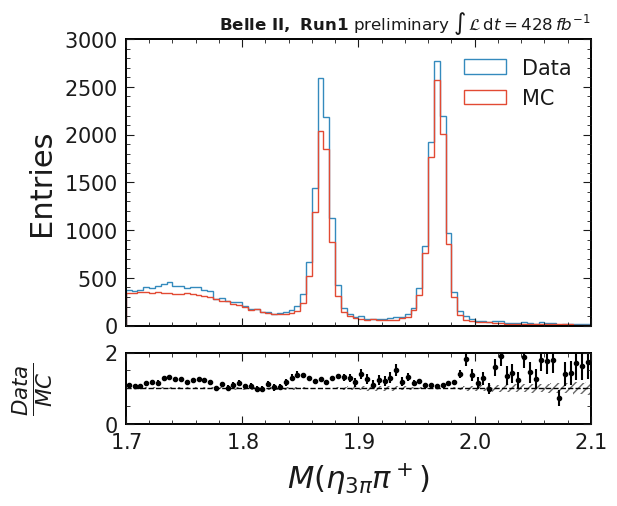

In [121]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{3\pi} \pi^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.7,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)
# h2 = make_hist(x2, bins=80, range=x_range, weights=(1/4)*0.7)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_ref_{name}_skimhad_Dp_CMS_p.png", bbox_inches="tight")

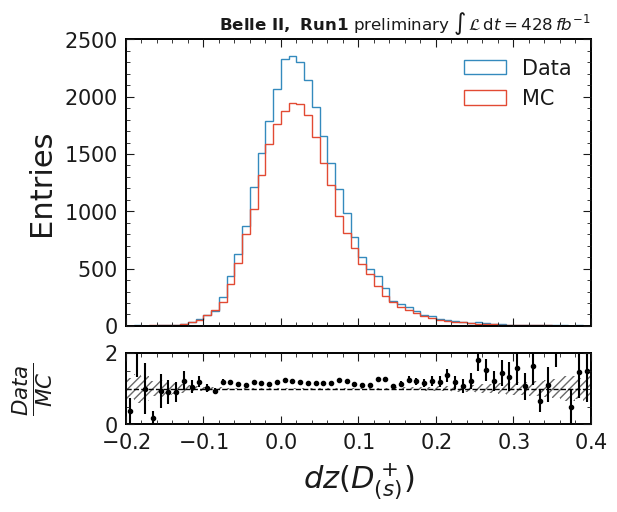

In [122]:
name = "Dp_dz"
category = "category"
xlabel = r"$dz(D^+_{(s)})$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (-0.2,0.4)

h1 = make_hist(x1, bins=60, range=x_range, weights=1)
h2 = make_hist(x2, bins=60, range=x_range, weights=1/4)
# h2 = make_hist(x2, bins=80, range=x_range, weights=(1/4)*0.7)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_ref_{name}_skimhad_Dp_CMS_p.png", bbox_inches="tight")

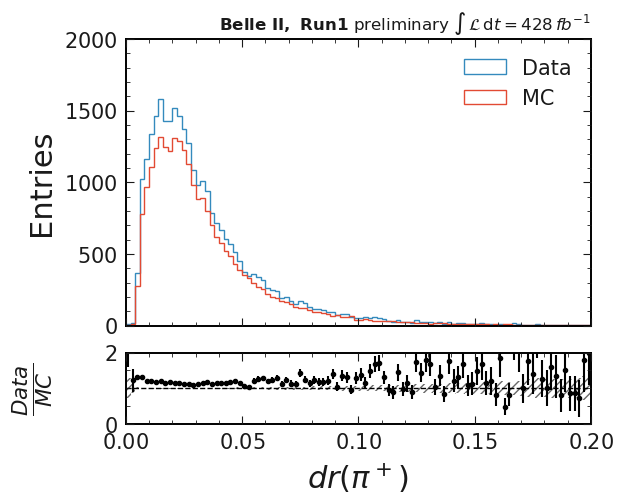

In [123]:
name = "Pip_dr"
category = "category"
xlabel = r'$dr(\pi^+)$'

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (0,0.2)

h1 = make_hist(x1, bins=100, range=x_range, weights=1)
h2 = make_hist(x2, bins=100, range=x_range, weights=1/4)
# h2 = make_hist(x2, bins=80, range=x_range, weights=(1/4)*0.7)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_ref_{name}_skimhad_Dp_CMS_p.png", bbox_inches="tight")

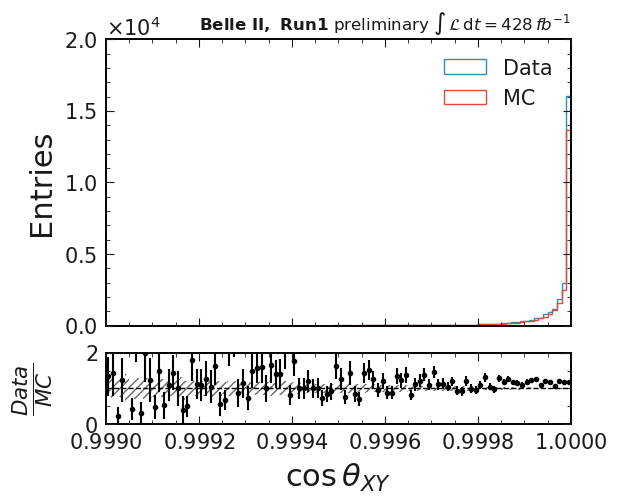

In [124]:
name = "Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane"
category = "category"
xlabel = r'$\cos \theta_{XY}$'

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (0.999,1)

h1 = make_hist(x1, bins=100, range=x_range, weights=1)
h2 = make_hist(x2, bins=100, range=x_range, weights=1/4)
# h2 = make_hist(x2, bins=100, range=x_range, weights=(1/4)*0.7)

# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)

fig.savefig(f"proc13_MC15rd_{tree_to_compare}_ref_{name}_skimhad_Dp_CMS_p.png", bbox_inches="tight")

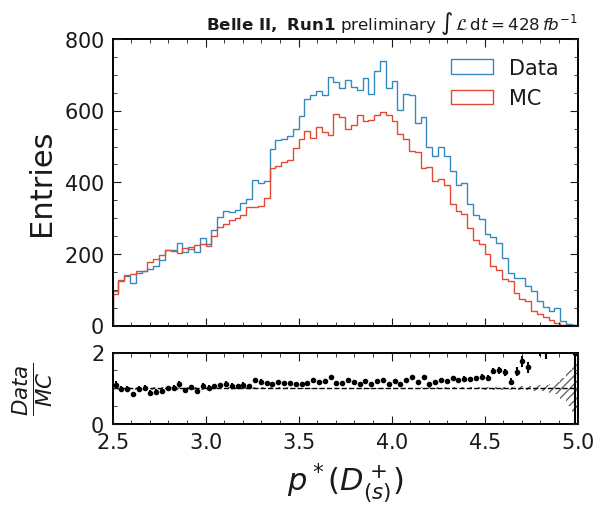

In [125]:
name = "Dp_CMS_p"
category = "category"
xlabel = r'$p^*(D^+_{(s)})$'

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (2.5,5.0)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)
# h2 = make_hist(x2, bins=80, range=x_range, weights=(1/4)*0.7)

# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)

fig.savefig(f"proc13_MC15rd_{tree_to_compare}_ref_{name}_skimhad_Dp_CMS_p.png", bbox_inches="tight")

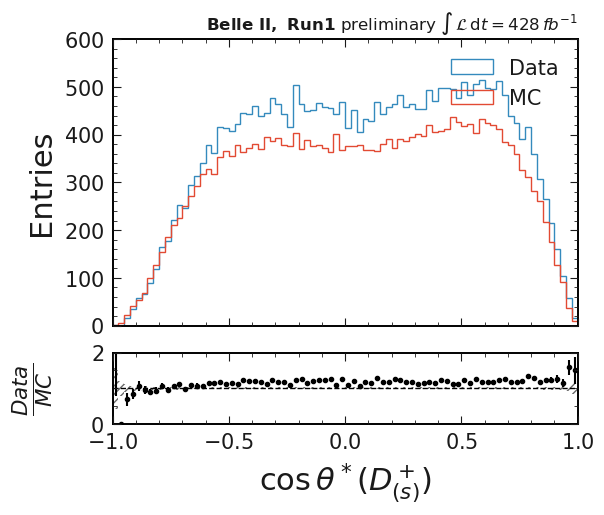

In [126]:
name = "Dp_CMS_cosTheta"
category = "category"
xlabel = r'$\cos\theta^*(D^+_{(s)})$'

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (-1,1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=(1/4))
# h2 = make_hist(x2, bins=80, range=x_range, weights=(1/4)*0.7)

# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
# plot_error_hist(h1, ax=ax_main, color="black", label="$h1_{err}$")

add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)

fig.savefig(f"proc13_MC15rd_{tree_to_compare}_ref_{name}_skimhad_Dp_CMS_p.png", bbox_inches="tight")